# 04 — Recommendation Engine

Pipeline lengkap dari input user → prediksi ML → rekomendasi makanan & olahraga.

```
User Input (Age, Height, Weight, Gender, FAF, FCVC, ...)
        ↓
  Feature Engineering (BMI, BMR, DailyCalorieTarget)
        ↓
  [obesity_model.pkl]  →  Obesity Class + Confidence
        ↓                           ↓
  Kalori Target              [obesity_to_exercise_map.json]
        ↓                           ↓
  Filter food_clean.csv      Filter gym_clean.csv
  per meal_type + kalori     per level + type
        ↓                           ↓
  Food Recommendations       Workout Recommendations
```

**Artifacts yang dibutuhkan (dari notebook 02 & 03):**
- `models/obesity_model.pkl`
- `models/label_encoders.pkl`
- `models/scaler.pkl`
- `models/model_meta.json`
- `data/processed/food_clean.csv`
- `data/processed/gym_clean.csv`
- `data/processed/obesity_to_exercise_map.json`

In [4]:
import pandas as pd
import numpy as np
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

# ── Load semua artifacts dari notebook sebelumnya ─────────────────
with open('../models/obesity_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('../models/label_encoders.pkl', 'rb') as f:
    le_dict = pickle.load(f)

with open('../models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('../models/model_meta.json') as f:
    meta = json.load(f)

with open('../data/processed/obesity_to_exercise_map.json') as f:
    exercise_map = json.load(f)

food_db = pd.read_csv('../data/processed/food_clean.csv')
gym_db  = pd.read_csv('../data/processed/gym_clean.csv')

FEATURES   = meta['features']   # 20 fitur
TARGET     = meta['target']     # NObeyesdad
CLASSES    = meta['classes']    # 7 label
le_target  = le_dict[TARGET]

print('Semua artifacts berhasil dimuat.')
print(f'Model     : {type(model).__name__}')
print(f'Food DB   : {food_db.shape}')
print(f'Gym DB    : {gym_db.shape}')
print(f'Features  : {len(FEATURES)} fitur')
print(f'Classes   : {CLASSES}')

Semua artifacts berhasil dimuat.
Model     : RandomForestClassifier
Food DB   : (581, 14)
Gym DB    : (2909, 7)
Features  : 20 fitur
Classes   : ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']


---
## 1. Eksplorasi Database Rekomendasi
Pahami struktur food & gym sebelum membuat fungsi filter.

In [5]:
print('=== FOOD DATABASE ===')
print(f'Kolom  : {food_db.columns.tolist()}')
print(f'Shape  : {food_db.shape}')
print(f'\nmeal_type unik  : {sorted(food_db["meal_type"].unique())}')
print(f'category unik   : {sorted(food_db["category"].unique())}')
print(f'calorie_category: {food_db["calorie_category"].value_counts().to_dict()}')
print(f'\nStats kalori:')
print(food_db['calories'].describe().round(1))
food_db.head(3)

=== FOOD DATABASE ===
Kolom  : ['food_name', 'category', 'calories', 'protein_g', 'carbs_g', 'fat_g', 'fiber_g', 'sugars_g', 'sodium_mg', 'cholesterol_mg', 'meal_type', 'water_ml', 'calorie_category', 'health_score']
Shape  : (581, 14)

meal_type unik  : ['breakfast', 'dinner', 'lunch', 'side', 'snack']
category unik   : ['beverage', 'beverage/dairy', 'beverage/dairy-alt', 'beverage/meal', 'condiment', 'condiment/dairy', 'condiment/processed', 'dairy', 'dairy/dessert', 'dessert', 'fruit', 'grain', 'grain/dessert', 'grain/processed', 'legume', 'meal', 'meal/fish', 'meal/fruit', 'meal/grain', 'meal/legume', 'meal/meat', 'meal/pasta', 'meal/processed', 'meal/protein', 'meal/rice', 'meal/seafood', 'meal/soup', 'meal/vegetable', 'meal/vegetarian', 'nut', 'protein', 'protein/dairy', 'protein/fish', 'protein/meat', 'protein/processed', 'protein/seafood', 'protein/vegetarian', 'snack', 'snack/appetizer', 'snack/dessert', 'snack/processed', 'supplement', 'supplement/processed', 'vegetable', 've

,food_name,category,calories,protein_g,carbs_g,fat_g,fiber_g,sugars_g,sodium_mg,cholesterol_mg,meal_type,water_ml,calorie_category,health_score
0,Scrambled Eggs (2 large),protein/dairy,180,12.0,2.0,14.0,0.0,1.0,180,370,breakfast,250,medium,37.0
1,Whole Wheat Toast (1 slice),grain,80,4.0,14.0,1.0,2.0,2.0,140,0,breakfast,0,low,52.3
2,Coffee (black),beverage,5,0.3,0.0,0.1,0.0,0.0,5,0,breakfast,0,low,42.7


In [6]:
print('=== GYM DATABASE ===')
print(f'Kolom   : {gym_db.columns.tolist()}')
print(f'Shape   : {gym_db.shape}')
print(f'\nLevel   : {sorted(gym_db["Level"].unique())}')
print(f'Type    : {sorted(gym_db["Type"].unique())}')
print(f'BodyPart: {sorted(gym_db["BodyPart"].unique())}')
print(f'\nCount per level:')
print(gym_db['Level'].value_counts())
print(f'\nCount per type:')
print(gym_db['Type'].value_counts())
gym_db.head(3)

=== GYM DATABASE ===
Kolom   : ['Title', 'Desc', 'Type', 'BodyPart', 'Equipment', 'Level', 'Rating']
Shape   : (2909, 7)

Level   : ['beginner', 'expert', 'intermediate']
Type    : ['cardio', 'olympic weightlifting', 'plyometrics', 'powerlifting', 'strength', 'stretching', 'strongman']
BodyPart: ['abdominals', 'abductors', 'adductors', 'biceps', 'calves', 'chest', 'forearms', 'glutes', 'hamstrings', 'lats', 'lower back', 'middle back', 'neck', 'quadriceps', 'shoulders', 'traps', 'triceps']

Count per level:
Level
intermediate    2437
beginner         459
expert            13
Name: count, dtype: int64

Count per type:
Type
strength                 2536
stretching                147
plyometrics                97
powerlifting               37
cardio                     35
olympic weightlifting      35
strongman                  22
Name: count, dtype: int64


,Title,Desc,Type,BodyPart,Equipment,Level,Rating
0,Partner plank band row,The partner plank band row is an abdominal exe...,strength,abdominals,bands,intermediate,0.0
1,Banded crunch isometric hold,The banded crunch isometric hold is an exercis...,strength,abdominals,bands,intermediate,7.9
2,FYR Banded Plank Jack,The banded plank jack is a variation on the pl...,strength,abdominals,bands,intermediate,7.9


In [7]:
print('=== OBESITY → EXERCISE MAP ===')
print(json.dumps(exercise_map, indent=2, ensure_ascii=False))

=== OBESITY → EXERCISE MAP ===
{
  "Insufficient_Weight": {
    "level": "beginner",
    "preferred_type": [
      "strength"
    ],
    "note": "Fokus pada latihan kekuatan untuk menambah massa otot"
  },
  "Normal_Weight": {
    "level": "intermediate",
    "preferred_type": [
      "strength",
      "cardio"
    ],
    "note": "Kombinasi cardio dan strength untuk menjaga komposisi tubuh"
  },
  "Overweight_Level_I": {
    "level": "beginner",
    "preferred_type": [
      "cardio",
      "stretching"
    ],
    "note": "Mulai dengan cardio ringan dan stretching"
  },
  "Overweight_Level_II": {
    "level": "beginner",
    "preferred_type": [
      "cardio",
      "stretching"
    ],
    "note": "Prioritaskan cardio intensitas rendah"
  },
  "Obesity_Type_I": {
    "level": "beginner",
    "preferred_type": [
      "cardio",
      "stretching"
    ],
    "note": "Cardio low-impact seperti jalan kaki atau berenang"
  },
  "Obesity_Type_II": {
    "level": "beginner",
    "preferred_ty

---
## 2. Fungsi Inti: Prediksi ML

Replicates exact pipeline dari notebook 03 — feature engineering identik.

In [8]:
def predict_obesity_class(user_input: dict) -> dict:
    """
    Input  : dict dengan 16 kolom raw (nilai asli, belum di-encode).
    Output : dict berisi obesity_class, confidence, bmi, bmr, daily_calorie_target,
             activity_level, dan probabilitas per kelas.

    Kolom wajib:
      Gender, Age, Height (meter), Weight (kg),
      family_history_with_overweight, FAVC, FCVC, NCP,
      CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS
    """
    row = user_input.copy()

    h   = float(row['Height'])
    w   = float(row['Weight'])
    age = float(row['Age'])
    g   = str(row['Gender']).strip().lower()

    # ── Feature Engineering (identik dengan notebook 02) ──────────
    row['BMI'] = round(w / (h ** 2), 2)

    h_cm = h * 100
    if 'female' in g:
        row['BMR'] = round(447.593 + (9.247*w) + (3.098*h_cm) - (4.330*age), 2)
    else:
        row['BMR'] = round(88.362 + (13.397*w) + (4.799*h_cm) - (5.677*age), 2)

    activity_mult            = {0: 1.2, 1: 1.375, 2: 1.55, 3: 1.725}
    row['ActivityLevel']     = min(int(round(float(row['FAF']))), 3)
    row['DailyCalorieTarget'] = int(row['BMR'] * activity_mult[row['ActivityLevel']])

    # ── Label Encoding ────────────────────────────────────────────
    df_row = pd.DataFrame([row])
    for col, le in le_dict.items():
        if col in df_row.columns and col != TARGET:
            df_row[col] = le.transform(df_row[col].astype(str))

    # ── Scale & Predict ───────────────────────────────────────────
    df_row    = df_row.reindex(columns=FEATURES, fill_value=0)
    df_scaled = scaler.transform(df_row)

    pred_idx   = model.predict(df_scaled)[0]
    pred_proba = model.predict_proba(df_scaled)[0]
    pred_label = le_target.inverse_transform([pred_idx])[0]

    return {
        'obesity_class':        pred_label,
        'confidence_pct':       round(float(pred_proba.max()) * 100, 1),
        'bmi':                  row['BMI'],
        'bmr':                  row['BMR'],
        'daily_calorie_target': row['DailyCalorieTarget'],
        'activity_level':       row['ActivityLevel'],  # key lowercase, value dari row['ActivityLevel']
        'class_probabilities': {
            cls: round(float(p)*100, 1)
            for cls, p in zip(CLASSES, pred_proba)
        }
    }

# Smoke test
test_pred = predict_obesity_class({
    'Gender': 'Male', 'Age': 25, 'Height': 1.75, 'Weight': 70,
    'family_history_with_overweight': 'no', 'FAVC': 'no',
    'FCVC': 2, 'NCP': 3, 'CAEC': 'Sometimes', 'SMOKE': 'no',
    'CH2O': 2, 'SCC': 'no', 'FAF': 2, 'TUE': 1,
    'CALC': 'Sometimes', 'MTRANS': 'Public_Transportation'
})
print('Smoke test — predict_obesity_class:')
for k, v in test_pred.items():
    if k != 'class_probabilities':
        print(f'  {k}: {v}')

Smoke test — predict_obesity_class:
  obesity_class: Normal_Weight
  confidence_pct: 94.8
  bmi: 22.86
  bmr: 1724.05
  daily_calorie_target: 2672
  activity_level: 2


---
## 3. Fungsi Inti: Food Recommendation

Strategi distribusi kalori harian:
- Sarapan  : 25%
- Makan siang: 35%
- Makan malam: 30%
- Snack       : 10%

In [9]:
# Distribusi kalori per meal
MEAL_CALORIE_RATIO = {
    'breakfast': 0.25,
    'lunch':     0.35,
    'dinner':    0.30,
    'snack':     0.10,
}

# Toleransi ±25% dari target kalori per meal
CALORIE_TOLERANCE = 0.25

# Obesity class → diet modifier
# Kelas tertentu perlu adjustment kalori untuk weight loss / gain
OBESITY_CALORIE_MODIFIER = {
    'Insufficient_Weight': 1.15,   # +15% untuk weight gain
    'Normal_Weight':       1.00,   # maintenance
    'Overweight_Level_I':  0.90,   # -10% deficit ringan
    'Overweight_Level_II': 0.85,   # -15% deficit sedang
    'Obesity_Type_I':      0.80,   # -20% deficit
    'Obesity_Type_II':     0.75,   # -25% deficit
    'Obesity_Type_III':    0.70,   # -30% deficit (harus konsultasi dokter)
}

def recommend_food(
    obesity_class: str,
    daily_calorie_target: int,
    n_per_meal: int = 3,
    random_state: int = 42
) -> dict:
    """
    Mengembalikan dict berisi rekomendasi makanan per meal_type,
    sudah disesuaikan dengan obesity class (calorie modifier).

    Args:
        obesity_class         : label kelas dari ML model
        daily_calorie_target  : hasil kalkulasi BMR × activity multiplier
        n_per_meal            : jumlah rekomendasi per meal
        random_state          : untuk reproducibility

    Returns:
        {
          'adjusted_daily_calories': int,
          'calorie_modifier': float,
          'meal_targets': { meal: kcal },
          'recommendations': { meal: [list of food dicts] },
          'total_recommended_calories': int
        }
    """
    modifier = OBESITY_CALORIE_MODIFIER.get(obesity_class, 1.0)
    adjusted_calories = int(daily_calorie_target * modifier)

    meal_targets = {
        meal: int(adjusted_calories * ratio)
        for meal, ratio in MEAL_CALORIE_RATIO.items()
    }

    recommendations = {}
    total_rec_cal   = 0

    for meal, target_cal in meal_targets.items():
        low  = target_cal * (1 - CALORIE_TOLERANCE)
        high = target_cal * (1 + CALORIE_TOLERANCE)

        # Filter meal_type + rentang kalori
        mask = (
            food_db['meal_type'].str.contains(meal, case=False, na=False) &
            (food_db['calories'] >= low) &
            (food_db['calories'] <= high)
        )
        filtered = food_db[mask].copy()

        # Fallback: kalau tidak ada yang match persis,
        # ambil meal_type yang match saja, urutkan by |delta kalori|
        if len(filtered) < n_per_meal:
            fallback = food_db[
                food_db['meal_type'].str.contains(meal, case=False, na=False)
            ].copy()
            fallback['_cal_delta'] = (fallback['calories'] - target_cal).abs()
            filtered = fallback.nsmallest(n_per_meal * 3, '_cal_delta').drop(columns='_cal_delta')

        # Urutkan by health_score DESC, sample n_per_meal
        filtered = filtered.sort_values('health_score', ascending=False)
        selected = filtered.head(n_per_meal * 3).sample(
            min(n_per_meal, len(filtered)),
            random_state=random_state
        )

        cols_out = ['food_name', 'calories', 'protein_g', 'carbs_g',
                    'fat_g', 'fiber_g', 'meal_type', 'health_score']
        cols_out = [c for c in cols_out if c in selected.columns]

        recommendations[meal] = selected[cols_out].to_dict(orient='records')
        total_rec_cal += int(selected['calories'].sum())

    return {
        'adjusted_daily_calories':     adjusted_calories,
        'calorie_modifier':            modifier,
        'meal_targets':                meal_targets,
        'recommendations':             recommendations,
        'total_recommended_calories':  total_rec_cal
    }

# Smoke test
food_result = recommend_food('Normal_Weight', 2300, n_per_meal=3)
print(f'Adjusted calories : {food_result["adjusted_daily_calories"]} kcal')
print(f'Modifier          : {food_result["calorie_modifier"]}')
print(f'Meal targets      : {food_result["meal_targets"]}')
print(f'Total rec cal     : {food_result["total_recommended_calories"]} kcal')
print(f'\nContoh breakfast :')
for item in food_result['recommendations']['breakfast']:
    print(f'  {item["food_name"]:30s} {item["calories"]:5.0f} kcal  score={item["health_score"]}')

Adjusted calories : 2300 kcal
Modifier          : 1.0
Meal targets      : {'breakfast': 575, 'lunch': 805, 'dinner': 690, 'snack': 230}
Total rec cal     : 5290 kcal

Contoh breakfast :
  Biscuits and Gravy (1 serving)   480 kcal  score=37.7
  Ham & Cheese Croissant           400 kcal  score=49.6
  Danish (Cheese 1 medium)         340 kcal  score=39.6


---
## 4. Fungsi Inti: Workout Recommendation

In [10]:
# Prioritas body part berdasarkan obesity class
OBESITY_BODYPART_PRIORITY = {
    'Insufficient_Weight': ['chest', 'back', 'shoulders', 'biceps', 'triceps', 'legs'],
    'Normal_Weight':       ['abdominals', 'chest', 'back', 'legs', 'shoulders'],
    'Overweight_Level_I':  ['abdominals', 'cardio', 'legs', 'back'],
    'Overweight_Level_II': ['cardio', 'abdominals', 'legs'],
    'Obesity_Type_I':      ['cardio', 'abdominals', 'legs'],
    'Obesity_Type_II':     ['cardio', 'abdominals'],
    'Obesity_Type_III':    ['stretching', 'abdominals'],
}

def recommend_workout(
    obesity_class: str,
    n_recommendations: int = 5,
    random_state: int = 42
) -> dict:
    """
    Mengembalikan dict berisi rekomendasi workout berdasarkan obesity class.
    Filter: level + type dari obesity_to_exercise_map.json

    Args:
        obesity_class     : label kelas dari ML model
        n_recommendations : total latihan yang direkomendasikan
        random_state      : untuk reproducibility

    Returns:
        {
          'recommended_level'  : str,
          'preferred_types'    : list,
          'note'               : str,
          'by_bodypart'        : { bodypart: [list of exercise dicts] },
          'full_list'          : [list of exercise dicts]
        }
    """
    mapping = exercise_map.get(obesity_class, exercise_map['Normal_Weight'])
    level   = mapping['level']
    types   = mapping['preferred_type']
    note    = mapping['note']

    # Filter level + type
    mask = (
        (gym_db['Level'] == level) &
        (gym_db['Type'].isin(types))
    )
    filtered = gym_db[mask].copy()

    # Fallback: kalau kurang, relax filter ke level saja
    if len(filtered) < n_recommendations:
        filtered = gym_db[gym_db['Level'] == level].copy()

    # Ambil body part priority untuk kelas ini
    bp_priority = OBESITY_BODYPART_PRIORITY.get(obesity_class, [])

    cols_out = ['Title', 'Type', 'BodyPart', 'Equipment', 'Level', 'Rating']
    cols_out = [c for c in cols_out if c in filtered.columns]

    # Susun rekomendasi per body part priority
    by_bodypart = {}
    used_titles = set()

    n_per_bp = max(1, n_recommendations // max(len(bp_priority), 1))

    for bp in bp_priority:
        bp_mask = filtered['BodyPart'].str.contains(bp, case=False, na=False)
        bp_pool = filtered[bp_mask & ~filtered['Title'].isin(used_titles)]

        if len(bp_pool) == 0:
            continue

        # Sort by rating DESC, sample
        bp_pool = bp_pool.sort_values('Rating', ascending=False)
        selected = bp_pool.head(n_per_bp * 3).sample(
            min(n_per_bp, len(bp_pool)),
            random_state=random_state
        )
        by_bodypart[bp] = selected[cols_out].to_dict(orient='records')
        used_titles.update(selected['Title'].tolist())

    # Full list flatten (urut by priority)
    full_list = []
    for bp in bp_priority:
        full_list.extend(by_bodypart.get(bp, []))

    # Tambah sisa dari pool umum jika masih kurang
    if len(full_list) < n_recommendations:
        extra_pool = filtered[~filtered['Title'].isin(used_titles)]
        if len(extra_pool) > 0:
            extra = extra_pool.sample(
                min(n_recommendations - len(full_list), len(extra_pool)),
                random_state=random_state
            )
            full_list.extend(extra[cols_out].to_dict(orient='records'))

    return {
        'recommended_level': level,
        'preferred_types':   types,
        'note':              note,
        'by_bodypart':       by_bodypart,
        'full_list':         full_list[:n_recommendations]
    }

# Smoke test
workout_result = recommend_workout('Obesity_Type_I', n_recommendations=6)
print(f'Level : {workout_result["recommended_level"]}')
print(f'Types : {workout_result["preferred_types"]}')
print(f'Note  : {workout_result["note"]}')
print(f'\nRekomendasi (full list):')
for ex in workout_result['full_list']:
    print(f'  [{ex["BodyPart"]:12s}] {ex["Title"]}')

Level : beginner
Types : ['cardio', 'stretching']
Note  : Cardio low-impact seperti jalan kaki atau berenang

Rekomendasi (full list):
  [abdominals  ] Stomach Vacuum
  [forearms    ] Kneeling Forearm Stretch
  [adductors   ] Adductor SMR
  [lower back  ] Crossover Reverse Lunge
  [adductors   ] Side Leg Raises
  [quadriceps  ] All Fours Quad Stretch


---
## 5. Pipeline Lengkap: `get_health_recommendations()`

Fungsi utama yang akan di-call oleh backend FastAPI.

In [11]:
# BMI category label untuk UI
def bmi_category(bmi: float) -> str:
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25.0:
        return 'Normal'
    elif bmi < 30.0:
        return 'Overweight'
    elif bmi < 35.0:
        return 'Obese Class I'
    elif bmi < 40.0:
        return 'Obese Class II'
    else:
        return 'Obese Class III'


def get_health_recommendations(
    user_input: dict,
    n_food_per_meal: int = 3,
    n_workout: int = 6
) -> dict:
    """
    Pipeline utama — dipanggil oleh FastAPI endpoint POST /predict.

    Input  : dict raw user input (16 kolom original obesity dataset)
    Output : dict lengkap siap dijadikan JSON response
    """
    # Step 1 — Prediksi
    pred = predict_obesity_class(user_input)

    # Step 2 — Food recommendation
    food_recs = recommend_food(
        obesity_class        = pred['obesity_class'],
        daily_calorie_target = pred['daily_calorie_target'],
        n_per_meal           = n_food_per_meal
    )

    # Step 3 — Workout recommendation
    workout_recs = recommend_workout(
        obesity_class     = pred['obesity_class'],
        n_recommendations = n_workout
    )

    return {
        'status': 'success',

        # Hasil prediksi ML
        'prediction': {
            'obesity_class':        pred['obesity_class'],
            'confidence_pct':       pred['confidence_pct'],
            'class_probabilities':  pred['class_probabilities']
        },

        # Analisis BMI
        'bmi_analysis': {
            'bmi':          pred['bmi'],
            'bmi_category': bmi_category(pred['bmi']),
            'bmr':          pred['bmr'],
            'activity_level': pred['activity_level'],  # match key dari predict_obesity_class
        },

        # Status kesehatan
        'health_status': {
            'obesity_class':           pred['obesity_class'],
            'daily_calorie_target':    pred['daily_calorie_target'],
            'adjusted_daily_calories': food_recs['adjusted_daily_calories'],
            'calorie_modifier':        food_recs['calorie_modifier'],
            'meal_targets':            food_recs['meal_targets']
        },

        # Rekomendasi makanan
        'food_recommendations': {
            'total_recommended_calories': food_recs['total_recommended_calories'],
            'meals': food_recs['recommendations']
        },

        # Rekomendasi olahraga
        'workout_recommendations': {
            'level':          workout_recs['recommended_level'],  # key 'level' untuk frontend
            'preferred_type': workout_recs['preferred_types'],
            'note':           workout_recs['note'],
            'exercises':      workout_recs['full_list']
        }
    }

print('Pipeline get_health_recommendations siap.')

Pipeline get_health_recommendations siap.


---
## 6. End-to-End Test — 4 Skenario User

Uji pipeline dengan profil yang representatif dari setiap rentang obesitas.

In [13]:
SCENARIOS = [
    ('Pria Normal 25th', {
        'Gender': 'Male',   'Age': 25, 'Height': 1.75, 'Weight': 70,
        'family_history_with_overweight': 'no',  'FAVC': 'no',
        'FCVC': 2, 'NCP': 3, 'CAEC': 'Sometimes',  'SMOKE': 'no',
        'CH2O': 2, 'SCC': 'no', 'FAF': 2, 'TUE': 1,
        'CALC': 'Sometimes', 'MTRANS': 'Public_Transportation'
    }),
    ('Wanita Kurus 20th', {
        'Gender': 'Female', 'Age': 20, 'Height': 1.60, 'Weight': 44,
        'family_history_with_overweight': 'no',  'FAVC': 'no',
        'FCVC': 3, 'NCP': 2, 'CAEC': 'no',         'SMOKE': 'no',
        'CH2O': 3, 'SCC': 'yes', 'FAF': 1, 'TUE': 0,
        'CALC': 'no',        'MTRANS': 'Walking'
    }),
    ('Pria Obesitas I 35th', {
        'Gender': 'Male',   'Age': 35, 'Height': 1.70, 'Weight': 100,
        'family_history_with_overweight': 'yes', 'FAVC': 'yes',
        'FCVC': 1, 'NCP': 4, 'CAEC': 'Frequently', 'SMOKE': 'no',
        'CH2O': 1, 'SCC': 'no', 'FAF': 0, 'TUE': 3,
        'CALC': 'Frequently', 'MTRANS': 'Automobile'
    }),
    ('Wanita Obesitas III 45th', {
        'Gender': 'Female', 'Age': 45, 'Height': 1.58, 'Weight': 130,
        'family_history_with_overweight': 'yes', 'FAVC': 'yes',
        'FCVC': 1, 'NCP': 4, 'CAEC': 'Always',    'SMOKE': 'yes',
        'CH2O': 1, 'SCC': 'no', 'FAF': 0, 'TUE': 4,
        'CALC': 'Always',    'MTRANS': 'Automobile'
    }),
]

results_cache = {}

for scenario_name, user_input in SCENARIOS:
    print('='*60)
    print(f'SKENARIO: {scenario_name}')
    print('='*60)

    result = get_health_recommendations(user_input, n_food_per_meal=2, n_workout=4)
    results_cache[scenario_name] = result

    p  = result['prediction']
    b  = result['bmi_analysis']
    hs = result['health_status']
    fr = result['food_recommendations']
    wr = result['workout_recommendations']

    print(f'  Kelas Obesitas  : {p["obesity_class"]} ({p["confidence_pct"]}% confidence)')
    print(f'  BMI             : {b["bmi"]} ({b["bmi_category"]})')
    print(f'  BMR             : {b["bmr"]} kcal')
    print(f'  Kalori TDEE     : {hs["daily_calorie_target"]} kcal')
    print(f'  Kalori Adjusted : {hs["adjusted_daily_calories"]} kcal (modifier={hs["calorie_modifier"]})')
    print(f'  Meal targets    : {hs["meal_targets"]}')

    print(f'\n  FOOD ({fr["total_recommended_calories"]} kcal total):')
    for meal, items in fr['meals'].items():
        print(f'    {meal.upper()}:')
        for item in items:
            print(f'      • {item["food_name"]:30s} {item["calories"]:5.0f} kcal')

    print(f'\n  WORKOUT [{wr["level"]}] ({wr["preferred_type"]})')
    print(f'  Catatan: {wr["note"]}')
    for ex in wr['exercises']:
        print(f'    • [{ex.get("bodypart","?"):12s}] {ex["Title"]}')
    print()

SKENARIO: Pria Normal 25th
  Kelas Obesitas  : Normal_Weight (94.8% confidence)
  BMI             : 22.86 (Normal)
  BMR             : 1724.05 kcal
  Kalori TDEE     : 2672 kcal
  Kalori Adjusted : 2672 kcal (modifier=1.0)
  Meal targets    : {'breakfast': 668, 'lunch': 935, 'dinner': 801, 'snack': 267}

  FOOD (3720 kcal total):
    BREAKFAST:
      • Acai Bowl (1 serving)            350 kcal
      • Ham & Cheese Croissant           400 kcal
    LUNCH:
      • Chicken Parm Sandwich            650 kcal
      • Shawarma (Chicken 1 wrap)        550 kcal
    DINNER:
      • Beef Burrito (large)             650 kcal
      • Chicken Alfredo (1.5 cups)       680 kcal
    SNACK:
      • Protein Bar                      210 kcal
      • Kibbeh (1 piece fried)           230 kcal

  WORKOUT [intermediate] (['strength', 'cardio'])
  Catatan: Kombinasi cardio dan strength untuk menjaga komposisi tubuh
    • [?           ] Landmine twist
    • [?           ] Pushups
    • [?           ] T-Bar Row w

---
## 7. Validasi Konsistensi Pipeline

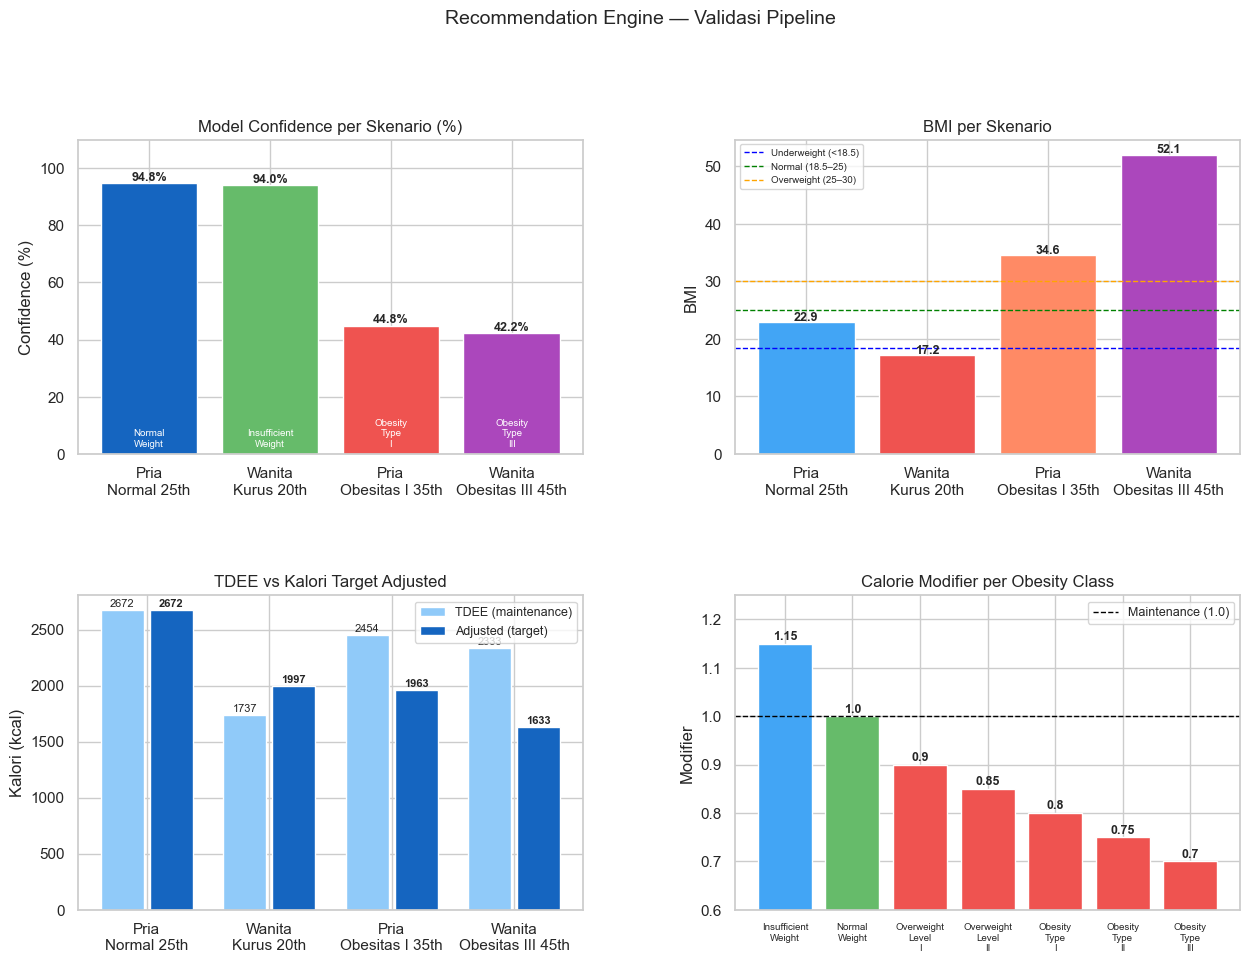

In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
sns.set_theme(style='whitegrid')

fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.3)

scenario_names  = list(results_cache.keys())
obesity_classes = [results_cache[s]['prediction']['obesity_class'] for s in scenario_names]
confidences     = [results_cache[s]['prediction']['confidence_pct'] for s in scenario_names]
bmis            = [results_cache[s]['bmi_analysis']['bmi'] for s in scenario_names]
tdees           = [results_cache[s]['health_status']['daily_calorie_target'] for s in scenario_names]
adj_cals        = [results_cache[s]['health_status']['adjusted_daily_calories'] for s in scenario_names]
modifiers       = [results_cache[s]['health_status']['calorie_modifier'] for s in scenario_names]

short_names = [s.split()[0] + '\n' + ' '.join(s.split()[1:]) for s in scenario_names]

# Plot 1 — Confidence per skenario
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(short_names, confidences, color=['#1565C0','#66BB6A','#EF5350','#AB47BC'], edgecolor='white')
ax1.set_ylim(0, 110)
ax1.set_title('Model Confidence per Skenario (%)')
ax1.set_ylabel('Confidence (%)')
for bar, cls in zip(bars, obesity_classes):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax1.text(bar.get_x() + bar.get_width()/2, 2,
             cls.replace('_', '\n'), ha='center', fontsize=7, color='white', va='bottom')

# Plot 2 — BMI per skenario
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(short_names, bmis, color=['#42A5F5','#EF5350','#FF8A65','#AB47BC'], edgecolor='white')
ax2.axhline(18.5, color='blue',   linestyle='--', linewidth=1, label='Underweight (<18.5)')
ax2.axhline(25.0, color='green',  linestyle='--', linewidth=1, label='Normal (18.5–25)')
ax2.axhline(30.0, color='orange', linestyle='--', linewidth=1, label='Overweight (25–30)')
ax2.set_title('BMI per Skenario')
ax2.set_ylabel('BMI')
ax2.legend(fontsize=7, loc='upper left')
for i, (bar_x, bmi) in enumerate(zip(range(len(short_names)), bmis)):
    ax2.text(bar_x, bmi + 0.3, f'{bmi:.1f}', ha='center', fontsize=9, fontweight='bold')

# Plot 3 — TDEE vs Adjusted calories
ax3 = fig.add_subplot(gs[1, 0])
x   = np.arange(len(short_names))
ax3.bar(x - 0.2, tdees,    0.35, label='TDEE (maintenance)', color='#90CAF9', edgecolor='white')
ax3.bar(x + 0.2, adj_cals, 0.35, label='Adjusted (target)',  color='#1565C0', edgecolor='white')
ax3.set_xticks(x)
ax3.set_xticklabels(short_names)
ax3.set_title('TDEE vs Kalori Target Adjusted')
ax3.set_ylabel('Kalori (kcal)')
ax3.legend(fontsize=9)
for i, (tdee, adj) in enumerate(zip(tdees, adj_cals)):
    ax3.text(i - 0.2, tdee + 30, f'{tdee}', ha='center', fontsize=8)
    ax3.text(i + 0.2, adj  + 30, f'{adj}',  ha='center', fontsize=8, fontweight='bold')

# Plot 4 — Calorie modifier per class
ax4 = fig.add_subplot(gs[1, 1])
all_classes  = list(OBESITY_CALORIE_MODIFIER.keys())
all_modifiers= list(OBESITY_CALORIE_MODIFIER.values())
colors_mod   = ['#EF5350' if m < 1 else '#66BB6A' if m == 1 else '#42A5F5' for m in all_modifiers]
ax4.bar([c.replace('_', '\n') for c in all_classes], all_modifiers, color=colors_mod, edgecolor='white')
ax4.axhline(1.0, color='black', linestyle='--', linewidth=1, label='Maintenance (1.0)')
ax4.set_title('Calorie Modifier per Obesity Class')
ax4.set_ylabel('Modifier')
ax4.set_ylim(0.6, 1.25)
ax4.legend(fontsize=9)
ax4.tick_params(axis='x', labelsize=7)
for i, (cls, mod) in enumerate(zip(all_classes, all_modifiers)):
    ax4.text(i, mod + 0.008, f'{mod}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Recommendation Engine — Validasi Pipeline', fontsize=14, y=1.01)
plt.savefig('../models/recommendation_validation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Export: Simpan Fungsi sebagai Module Backend

Fungsi-fungsi di atas akan di-import langsung oleh `backend/recommender.py`.

In [15]:
import os
os.makedirs('../backend', exist_ok=True)

recommender_code = '''
"""
backend/recommender.py
Recommendation Engine — AI Personal Health & Nutrition Advisor
Di-generate dari notebook 04_recommendation_engine.ipynb
"""

import pandas as pd
import numpy as np
import pickle
import json
from pathlib import Path

BASE_DIR   = Path(__file__).parent.parent
MODELS_DIR = BASE_DIR / "models"
DATA_DIR   = BASE_DIR / "data" / "processed"

# ── Load artifacts ────────────────────────────────────────────────
with open(MODELS_DIR / "obesity_model.pkl", "rb") as f:
    model = pickle.load(f)

with open(MODELS_DIR / "label_encoders.pkl", "rb") as f:
    le_dict = pickle.load(f)

with open(MODELS_DIR / "scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

with open(MODELS_DIR / "model_meta.json") as f:
    meta = json.load(f)

with open(DATA_DIR / "obesity_to_exercise_map.json") as f:
    exercise_map = json.load(f)

food_db = pd.read_csv(DATA_DIR / "food_clean.csv")
gym_db  = pd.read_csv(DATA_DIR / "gym_clean.csv")

FEATURES  = meta["features"]
TARGET    = meta["target"]
CLASSES   = meta["classes"]
le_target = le_dict[TARGET]

MEAL_CALORIE_RATIO = {
    "breakfast": 0.25,
    "lunch":     0.35,
    "dinner":    0.30,
    "snack":     0.10,
}

OBESITY_CALORIE_MODIFIER = {
    "Insufficient_Weight": 1.15,
    "Normal_Weight":       1.00,
    "Overweight_Level_I":  0.90,
    "Overweight_Level_II": 0.85,
    "Obesity_Type_I":      0.80,
    "Obesity_Type_II":     0.75,
    "Obesity_Type_III":    0.70,
}

OBESITY_BODYPART_PRIORITY = {
    "Insufficient_Weight": ["chest", "back", "shoulders", "biceps", "triceps", "legs"],
    "Normal_Weight":       ["abdominals", "chest", "back", "legs", "shoulders"],
    "Overweight_Level_I":  ["abdominals", "cardio", "legs", "back"],
    "Overweight_Level_II": ["cardio", "abdominals", "legs"],
    "Obesity_Type_I":      ["cardio", "abdominals", "legs"],
    "Obesity_Type_II":     ["cardio", "abdominals"],
    "Obesity_Type_III":    ["stretching", "abdominals"],
}

CALORIE_TOLERANCE = 0.25


def bmi_category(bmi: float) -> str:
    if bmi < 18.5:  return "Underweight"
    elif bmi < 25:  return "Normal"
    elif bmi < 30:  return "Overweight"
    elif bmi < 35:  return "Obese Class I"
    elif bmi < 40:  return "Obese Class II"
    else:           return "Obese Class III"


def predict_obesity_class(user_input: dict) -> dict:
    row = user_input.copy()
    h, w, age = float(row["Height"]), float(row["Weight"]), float(row["Age"])
    g = str(row["Gender"]).strip().lower()
    row["BMI"] = round(w / (h ** 2), 2)
    h_cm = h * 100
    row["BMR"] = round(
        (447.593 + 9.247*w + 3.098*h_cm - 4.330*age) if "female" in g
        else (88.362 + 13.397*w + 4.799*h_cm - 5.677*age), 2
    )
    mult = {0: 1.2, 1: 1.375, 2: 1.55, 3: 1.725}
    row["ActivityLevel"]      = min(int(round(float(row["FAF"]))), 3)
    row["DailyCalorieTarget"] = int(row["BMR"] * mult[row["ActivityLevel"]])

    df_row = pd.DataFrame([row])
    for col, le in le_dict.items():
        if col in df_row.columns and col != TARGET:
            df_row[col] = le.transform(df_row[col].astype(str))
    df_row    = df_row.reindex(columns=FEATURES, fill_value=0)
    df_scaled = scaler.transform(df_row)

    pred_idx   = model.predict(df_scaled)[0]
    pred_proba = model.predict_proba(df_scaled)[0]
    pred_label = le_target.inverse_transform([pred_idx])[0]

    return {
        "obesity_class":        pred_label,
        "confidence_pct":       round(float(pred_proba.max()) * 100, 1),
        "bmi":                  row["BMI"],
        "bmr":                  row["BMR"],
        "daily_calorie_target": row["DailyCalorieTarget"],
        "activity_level":       row["ActivityLevel"],
        "class_probabilities":  {
            cls: round(float(p)*100, 1)
            for cls, p in zip(CLASSES, pred_proba)
        },
    }


def recommend_food(obesity_class, daily_calorie_target, n_per_meal=3, random_state=42):
    modifier          = OBESITY_CALORIE_MODIFIER.get(obesity_class, 1.0)
    adjusted_calories = int(daily_calorie_target * modifier)
    meal_targets = {
        meal: int(adjusted_calories * ratio)
        for meal, ratio in MEAL_CALORIE_RATIO.items()
    }
    recommendations = {}; total_rec_cal = 0
    for meal, target_cal in meal_targets.items():
        low, high = target_cal * (1 - CALORIE_TOLERANCE), target_cal * (1 + CALORIE_TOLERANCE)
        mask = (food_db["meal_type"].str.contains(meal, case=False, na=False) &
                food_db["calories"].between(low, high))
        filtered = food_db[mask].copy()
        if len(filtered) < n_per_meal:
            fb = food_db[food_db["meal_type"].str.contains(meal, case=False, na=False)].copy()
            fb["_d"] = (fb["calories"] - target_cal).abs()
            filtered = fb.nsmallest(n_per_meal*3, "_d").drop(columns="_d")
        selected = (filtered.sort_values("health_score", ascending=False)
                             .head(n_per_meal*3)
                             .sample(min(n_per_meal, len(filtered)), random_state=random_state))
        cols = [c for c in ["food_name","calories","protein_g","carbs_g",
                             "fat_g","fiber_g","meal_type","health_score"] if c in selected.columns]
        recommendations[meal] = selected[cols].to_dict(orient="records")
        total_rec_cal += int(selected["calories"].sum())
    return {"adjusted_daily_calories": adjusted_calories, "calorie_modifier": modifier,
            "meal_targets": meal_targets, "recommendations": recommendations,
            "total_recommended_calories": total_rec_cal}


def recommend_workout(obesity_class, n_recommendations=5, random_state=42):
    mapping = exercise_map.get(obesity_class, exercise_map["Normal_Weight"])
    level, types, note = mapping["level"], mapping["preferred_type"], mapping["note"]
    mask = (gym_db["Level"] == level) & (gym_db["Type"].isin(types))
    filtered = gym_db[mask].copy()
    if len(filtered) < n_recommendations:
        filtered = gym_db[gym_db["Level"] == level].copy()
    bp_priority = OBESITY_BODYPART_PRIORITY.get(obesity_class, [])
    cols = [c for c in ["Title","Type","BodyPart","Equipment","Level","Rating"] if c in filtered.columns]
    by_bodypart = {}; used = set()
    n_per_bp = max(1, n_recommendations // max(len(bp_priority), 1))
    for bp in bp_priority:
        pool = filtered[filtered["BodyPart"].str.contains(bp, case=False, na=False) & ~filtered["Title"].isin(used)]
        if not len(pool): continue
        sel = pool.sort_values("Rating", ascending=False).head(n_per_bp*3).sample(min(n_per_bp, len(pool)), random_state=random_state)
        by_bodypart[bp] = sel[cols].to_dict(orient="records")
        used.update(sel["Title"].tolist())
    full_list = [ex for bp in bp_priority for ex in by_bodypart.get(bp, [])]
    if len(full_list) < n_recommendations:
        extra = gym_db[~gym_db["Title"].isin(used)]
        if len(extra):
            full_list.extend(extra.sample(min(n_recommendations - len(full_list), len(extra)), random_state=random_state)[cols].to_dict(orient="records"))
    return {"recommended_level": level, "preferred_types": types, "note": note,
            "by_bodypart": by_bodypart, "full_list": full_list[:n_recommendations]}


def get_health_recommendations(user_input, n_food_per_meal=3, n_workout=6):
    pred        = predict_obesity_class(user_input)
    food_recs   = recommend_food(pred["obesity_class"], pred["daily_calorie_target"], n_food_per_meal)
    workout_recs= recommend_workout(pred["obesity_class"], n_workout)
    return {
        "status":     "success",
        "prediction": {"obesity_class": pred["obesity_class"],
                       "confidence_pct": pred["confidence_pct"],
                       "class_probabilities": pred["class_probabilities"]},
        "bmi_analysis": {"bmi": pred["bmi"], "bmi_category": bmi_category(pred["bmi"]),
                         "bmr": pred["bmr"], "activity_level": pred["activity_level"]},
        "health_status": {"obesity_class": pred["obesity_class"],
                          "daily_calorie_target": pred["daily_calorie_target"],
                          "adjusted_daily_calories": food_recs["adjusted_daily_calories"],
                          "calorie_modifier": food_recs["calorie_modifier"],
                          "meal_targets": food_recs["meal_targets"]},
        "food_recommendations":    {"total_recommended_calories": food_recs["total_recommended_calories"],
                                    "meals": food_recs["recommendations"]},
        "workout_recommendations": {"level": workout_recs["recommended_level"],
                                    "preferred_type": workout_recs["preferred_types"],
                                    "note": workout_recs["note"],
                                    "exercises": workout_recs["full_list"]},
    }
'''

with open('../backend/recommender.py', 'w') as f:
    f.write(recommender_code.strip())

print('Saved: backend/recommender.py')
print('\nFungsi yang tersedia:')
print('  predict_obesity_class(user_input)             → dict prediksi ML')
print('  recommend_food(obesity_class, calorie_target) → dict food recs')
print('  recommend_workout(obesity_class)              → dict workout recs')
print('  get_health_recommendations(user_input)        → dict response lengkap (dipanggil FastAPI)')

Saved: backend/recommender.py

Fungsi yang tersedia:
  predict_obesity_class(user_input)             → dict prediksi ML
  recommend_food(obesity_class, calorie_target) → dict food recs
  recommend_workout(obesity_class)              → dict workout recs
  get_health_recommendations(user_input)        → dict response lengkap (dipanggil FastAPI)


---
## Summary

| Fungsi | Input | Output |
|--------|-------|--------|
| `predict_obesity_class` | dict 16 kolom raw | obesity class, confidence, bmi, bmr, calorie target |
| `recommend_food` | obesity_class, calorie_target | makanan per meal type + adjusted calories |
| `recommend_workout` | obesity_class | latihan per body part priority + level |
| `get_health_recommendations` | dict 16 kolom raw | response JSON lengkap untuk frontend |

**File yang dihasilkan:**
- `backend/recommender.py` — module siap di-import FastAPI
- `models/recommendation_validation.png` — plot validasi 4 skenario

**Tahap selanjutnya:** `backend/main.py` — FastAPI endpoint yang mengimport `recommender.py`